In [8]:
#linear regression model
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [12]:
#load the dataset
data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['Price'] = data.target
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [13]:
#exploration.
df.describe()
df.isnull().sum()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [15]:
df.corr()['Price'].sort_values(ascending=False)

Price         1.000000
MedInc        0.688075
AveRooms      0.151948
HouseAge      0.105623
AveOccup     -0.023737
Population   -0.024650
Longitude    -0.045967
AveBedrms    -0.046701
Latitude     -0.144160
Name: Price, dtype: float64

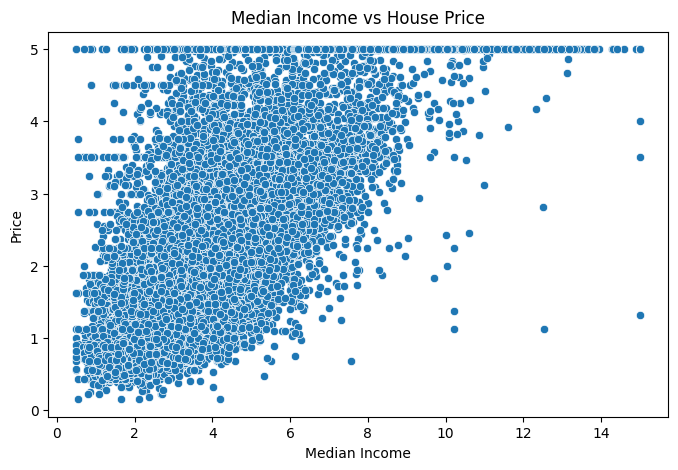

In [16]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['MedInc'], y=df['Price'])
plt.title('Median Income vs House Price')
plt.xlabel('Median Income')
plt.ylabel('Price')
plt.show()

In [17]:
X = df.drop('Price', axis=1)
y = df['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape, X_test.shape)

(16512, 8) (4128, 8)


In [18]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](8,)","[ 0.45, 0.01,-0.12,...,-0. ,-0.42,-0.43]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](8,)","['MedInc','HouseAge','AveRooms',...,'AveOccup','Latitude','Longitude']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-37.02
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(8)


In [20]:
#make prediction on test data
predictions = model.predict(X_test)

In [21]:
#evaluate the model how good it is working
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print("RMSE:", rmse)
print("R² Score:", r2)

RMSE: 0.745581383012776
R² Score: 0.5757877060324512


In [22]:
#see which feature mattered most. 
coefficients = pd.DataFrame(model.coef_, X.columns, columns=['Coefficient'])
print(coefficients)

            Coefficient
MedInc         0.448675
HouseAge       0.009724
AveRooms      -0.123323
AveBedrms      0.783145
Population    -0.000002
AveOccup      -0.003526
Latitude      -0.419792
Longitude     -0.433708


In [ ]:
#prepare data as numpy arrays. 
X_train_np = X_train.values
X_test_np = X_test.values
y_train_np = y_train.values
y_test_np = y_test.values

# Feature scaling (important for gradient descent to work well)
#standardize everything to have mean 0 and standard deviation 1
mean = X_train_np.mean(axis=0)
std = X_train_np.std(axis=0)
X_train_scaled = (X_train_np - mean) / std
X_test_scaled = (X_test_np - mean) / std



In [27]:
#initialize parameters
#all start with 0 and all bias start with 0 you will take 1000 small steps downhill each of size is learning rate.
n_samples, n_features = X_train_scaled.shape
weights = np.zeros(n_features)
bias = 0
learning_rate = 0.01
n_iterations = 1000

In [28]:
#gradient descent loop.
cost_history = []

for i in range(n_iterations):        #predict measure error 
    y_pred = np.dot(X_train_scaled, weights) + bias
    
    error = y_pred - y_train_np
    cost = (1/n_samples) * np.sum(error**2)
    cost_history.append(cost)
    
    dw = (2/n_samples) * np.dot(X_train_scaled.T, error)
    db = (2/n_samples) * np.sum(error)
    
    weights -= learning_rate * dw
    bias -= learning_rate * db

    if i % 100 == 0:                  #calculate gradient descent
        print(f"Iteration {i}: Cost = {cost:.4f}")

Iteration 0: Cost = 5.6297
Iteration 100: Cost = 0.7104
Iteration 200: Cost = 0.5953
Iteration 300: Cost = 0.5732
Iteration 400: Cost = 0.5584
Iteration 500: Cost = 0.5477
Iteration 600: Cost = 0.5398
Iteration 700: Cost = 0.5341
Iteration 800: Cost = 0.5299
Iteration 900: Cost = 0.5269


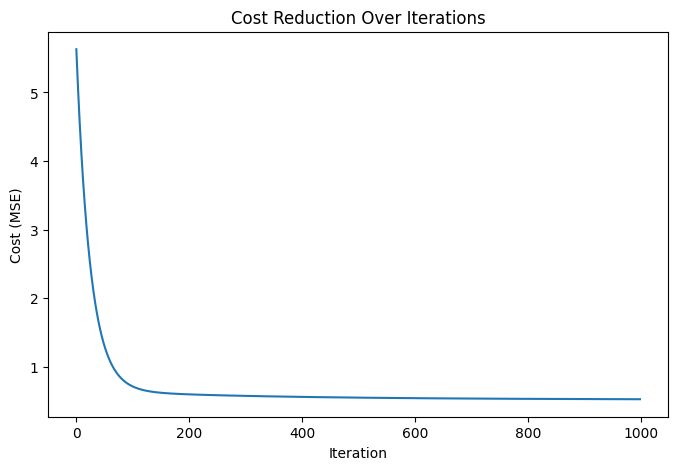

In [29]:
#plot cost curve 
plt.figure(figsize=(8,5))
plt.plot(range(n_iterations), cost_history)
plt.title('Cost Reduction Over Iterations')
plt.xlabel('Iteration')
plt.ylabel('Cost (MSE)')
plt.show()

In [30]:
y_pred_scratch = np.dot(X_test_scaled, weights) + bias

rmse_scratch = np.sqrt(mean_squared_error(y_test_np, y_pred_scratch))
r2_scratch = r2_score(y_test_np, y_pred_scratch)

print("From-Scratch RMSE:", rmse_scratch)
print("From-Scratch R²:", r2_scratch)

From-Scratch RMSE: 0.7447009510742285
From-Scratch R²: 0.5767889905063601


In [31]:
#compare both model 
comparison = pd.DataFrame({
    'Model': ['Scikit-learn', 'From Scratch'],
    'RMSE': [rmse, rmse_scratch],
    'R2 Score': [r2, r2_scratch]
})
print(comparison)

          Model      RMSE  R2 Score
0  Scikit-learn  0.745581  0.575788
1  From Scratch  0.744701  0.576789
